In [10]:
GWAS_SNP <- read.csv("GWAS_SNP.csv", header = F, sep = ",")
head(GWAS_SNP, 2)

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19
,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<chr>,<chr>,<int>,<int>,<int>,<int>,<int>,<int>,<chr>
1,rs72823645,chr6,8359186,T,C,0.05,1.69,1.4020556,2.037080481,3.67e-08,NSCPO,EUR,837,7913,41075272,1,NA,NA,
2,rs28361060,chr6,32303848,A,G,0.22,0.75,0.6801652,0.827005011,7.97e-09,All cleft,EUR,2268,7913,41075272,1,NA,NA,


In [ ]:

GWAS_SNP$V10 <- as.numeric(GWAS_SNP$V10)
# significant: p <= 5E-08
significant <- GWAS_SNP[!is.na(GWAS_SNP$V10) & GWAS_SNP$V10 <= 5e-08, ]

# sub-significant: 5E-08 < p <= 1E-06
sub_significant <- GWAS_SNP[!is.na(GWAS_SNP$V10) & GWAS_SNP$V10 > 5e-08 & GWAS_SNP$V10 <= 1e-06, ]

sig_v1_unique <- unique(significant$V1[!is.na(significant$V1)])
sub_v1_unique <- unique(sub_significant$V1[!is.na(sub_significant$V1)])

n_sig <- length(sig_v1_unique)
n_sub <- length(sub_v1_unique)

cat("significant (p <= 5e-08) 去重后 V1 SNP 数量:", n_sig, "\n")
cat("sub-significant (5e-08 < p <= 1e-06) 去重后 V1 SNP 数量:", n_sub, "\n")

result <- data.frame(
  Group = c("significant", "sub-significant"),
  Unique_SNP_Count = c(n_sig, n_sub)
)
print(result)


significant (p <= 5e-08) 去重后 V1 SNP 数量: 822 
sub-significant (5e-08 < p <= 1e-06) 去重后 V1 SNP 数量: 656 
            Group Unique_SNP_Count
1     significant              822
2 sub-significant              656


In [ ]:
suppressPackageStartupMessages({
  library(dplyr)
  library(stringr)
  library(tidyr)
})


GWAS_SNP$V10 <- as.numeric(GWAS_SNP$V10)


GWAS_SNP$V12_clean <- tolower(trimws(GWAS_SNP$V12))

dat <- GWAS_SNP %>%
  mutate(
    Ancestry4 = case_when(
      str_detect(V12_clean, "eur") ~ "EUR",
      str_detect(V12_clean, "eas") ~ "EAS",
      str_detect(V12_clean, "afr") ~ "AFR",
      str_detect(V12_clean, "cross-ancestry|cross ancestry|across ancestry|multi-ancestry|multi ancestry") ~ "cross-ancestry",
      TRUE ~ NA_character_
    ),
    SigGroup = case_when(
      V10 <= 5e-08 ~ "Significant",
      V10 > 5e-08 & V10 <= 1e-06 ~ "Sub-Significant",
      TRUE ~ NA_character_
    )
  ) %>%
  filter(!is.na(Ancestry4), !is.na(SigGroup), !is.na(V1))


stat_df <- dat %>%
  distinct(Ancestry4, SigGroup, V1) %>%
  count(Ancestry4, SigGroup, name = "Unique_SNP_Count")

table_out <- stat_df %>%
  pivot_wider(
    names_from = SigGroup,
    values_from = Unique_SNP_Count,
    values_fill = 0
  ) %>%
  mutate(Total = rowSums(across(c(Significant, `Sub-Significant`)), na.rm = TRUE))

print(table_out)


# A tibble: 4 × 4
  Ancestry4      Significant `Sub-Significant` Total
  <chr>                <int>             <int> <dbl>
1 AFR                      2                18    20
2 EAS                    103               405   508
3 EUR                    743               221   964
4 cross-ancestry           4                16    20


In [ ]:
# =========================
# 6)  EUR BED 
#    chr, start, end, SNP_id, P-value
# =========================
eur_bed <- dat %>%
  filter(Ancestry4 == "EUR") %>%
  group_by(V1) %>%
  slice_min(order_by = V10, n = 1, with_ties = FALSE) %>%
  ungroup() %>%
  transmute(
    chr = V2,
    start = as.integer(V3) - 1L,
    end = as.integer(V3),
    SNP_id = V1,
    `P-value` = V10
  ) %>%
  filter(!is.na(chr), !is.na(start), !is.na(end), !is.na(SNP_id), !is.na(`P-value`)) %>%
  filter(start >= 0) %>%
  arrange(chr, start, end)


write.table(
  eur_bed,
  file = "EUR_SNP.bed",
  sep = "\t",
  quote = FALSE,
  row.names = FALSE,
  col.names = FALSE
)



Warning message:
“There were 2 warnings in `transmute()`.
The first warning was:
ℹ In argument: `start = as.integer(V3) - 1L`.
Caused by warning:
! 强制改变过程中产生了NA
ℹ Run `dplyr::last_dplyr_warnings()` to see the 1 remaining warning.”


chr,start,end,SNP_id,P-value
<chr>,<int>,<int>,<chr>,<dbl>
chr1,6081195,6081196,rs750677342,4.75e-07
chr1,24668549,24668550,rs186916951,1.38e-08
chr1,24669456,24669457,rs41268753,1.95e-15
chr1,24721295,24721296,rs113965554,4.55e-16
chr1,24757835,24757836,rs192987380,3.82e-08
chr1,24816852,24816853,rs112392969,7.57e-15
chr1,24824740,24824741,rs111718052,9.15e-15
chr1,24844900,24844901,rs112935205,7.03e-15
chr1,24877116,24877117,rs190272150,1.61e-07


导出完成: EUR_SNP.bed（无表头）和 EUR_SNP_with_header.tsv（有表头）


In [ ]:
# =========================
# 7)  AFR / EAS / cross-ancestry
#    column: chr, start, end, SNP_id, P-value
# =========================
groups_to_export <- c("AFR", "EAS", "cross-ancestry")

for (g in groups_to_export) {
  bed_df <- dat %>%
    filter(Ancestry4 == g) %>%
    group_by(V1) %>%
    slice_min(order_by = V10, n = 1, with_ties = FALSE) %>%
    ungroup() %>%
    transmute(
      chr = V2,
      start = as.integer(V3) - 1L,
      end = as.integer(V3),
      SNP_id = V1,
      `P-value` = V10
    ) %>%
    filter(!is.na(chr), !is.na(start), !is.na(end), !is.na(SNP_id), !is.na(`P-value`)) %>%
    filter(start >= 0) %>%
    arrange(chr, start, end)
  g_file <- gsub("-", "_", g)


  write.table(
    bed_df,
    file = paste0(g_file, "_SNP.bed"),
    sep = "\t",
    quote = FALSE,
    row.names = FALSE,
    col.names = FALSE
  )


已导出: AFR_SNP.bed 和 AFR_SNP_with_header.tsv ，记录数 = 20 
已导出: EAS_SNP.bed 和 EAS_SNP_with_header.tsv ，记录数 = 508 
已导出: cross_ancestry_SNP.bed 和 cross_ancestry_SNP_with_header.tsv ，记录数 = 19 


Warning message in grid.Call(C_stringMetric, as.graphicsAnnot(x$label)):
“PostScript字体数据库里找不到'Arial'这个字体系列”
Warning message in grid.Call(C_stringMetric, as.graphicsAnnot(x$label)):
“PostScript字体数据库里找不到'Arial'这个字体系列”
Warning message in grid.Call(C_stringMetric, as.graphicsAnnot(x$label)):
“PostScript字体数据库里找不到'Arial'这个字体系列”
Warning message in grid.Call(C_stringMetric, as.graphicsAnnot(x$label)):
“PostScript字体数据库里找不到'Arial'这个字体系列”
Warning message in grid.Call(C_stringMetric, as.graphicsAnnot(x$label)):
“PostScript字体数据库里找不到'Arial'这个字体系列”
Warning message in grid.Call(C_stringMetric, as.graphicsAnnot(x$label)):
“PostScript字体数据库里找不到'Arial'这个字体系列”
Warning message in grid.Call(C_stringMetric, as.graphicsAnnot(x$label)):
“PostScript字体数据库里找不到'Arial'这个字体系列”
Warning message in grid.Call(C_stringMetric, as.graphicsAnnot(x$label)):
“PostScript字体数据库里找不到'Arial'这个字体系列”
Warning message in grid.Call(C_stringMetric, as.graphicsAnnot(x$label)):
“PostScript字体数据库里找不到'Arial'这个字体系列”
Warning message in grid.Call

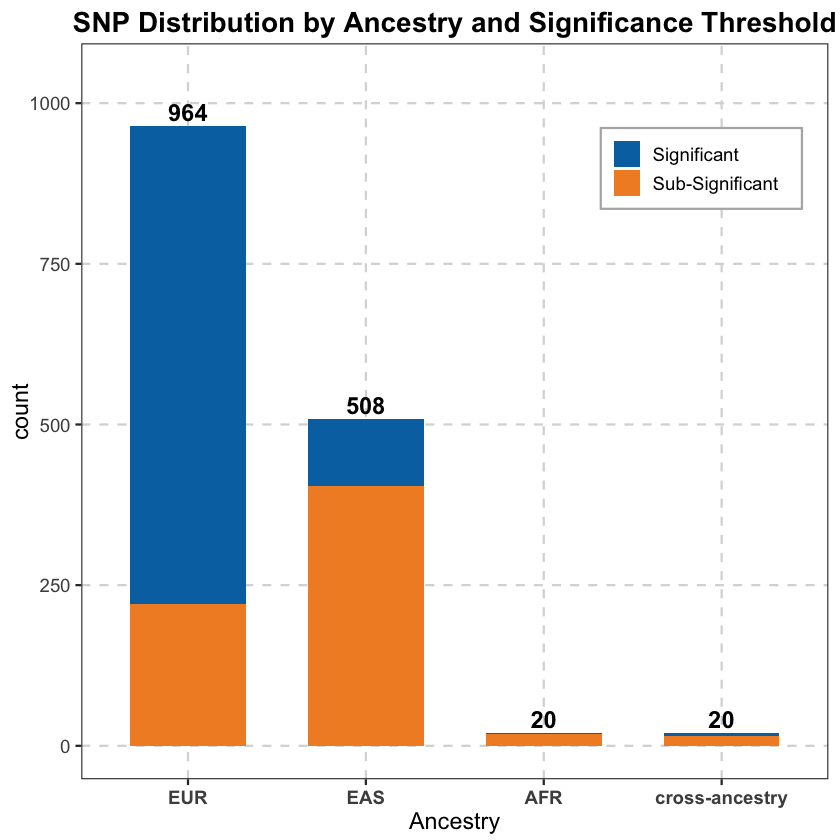

In [ ]:
# supplementary figure 4b:
library(ggplot2)
library(dplyr)

base_font <- "Arial"

label_df <- stat_df %>%
  group_by(Ancestry4) %>%
  summarise(Total = sum(Unique_SNP_Count), .groups = "drop")

p <- ggplot(stat_df, aes(x = Ancestry4, y = Unique_SNP_Count, fill = SigGroup)) +
  geom_col(width = 0.65) +
  geom_text(
    data = label_df,
    aes(x = Ancestry4, y = Total, label = Total),
    vjust = -0.35, size = 5, fontface = "bold", family = base_font, inherit.aes = FALSE
  ) +
  scale_fill_manual(values = c("Significant" = "#0072B2", "Sub-Significant" = "#F28E2B")) +
  labs(
    title = "SNP Distribution by Ancestry and Significance Threshold",
    x = "Ancestry",
    y = "count",
    fill = NULL
  ) +
  theme_bw(base_size = 14, base_family = base_font) +
  theme(
    plot.title = element_text(hjust = 0.5, face = "bold", family = base_font),
    legend.position = c(0.83, 0.83),
    legend.background = element_rect(fill = "white", color = "grey70"),
    panel.grid.major = element_line(color = "grey85", linetype = "dashed"),
    panel.grid.minor = element_blank(),
    axis.text.x = element_text(face = "bold", family = base_font),
    text = element_text(family = base_font)
  ) +
  expand_limits(y = max(label_df$Total) * 1.08)

print(p)

ggsave(
  "SNP_Ancestry_Significance_StackedBar_editable.pdf",
  plot = p,
  device = cairo_pdf,
  width = 6, height = 5
)


In [ ]:
#supplementary Figure 4C 
GWAS_interval <- GWAS_SNP %>%
  mutate(
    V10_num = as.numeric(V10),
    Pos     = as.integer(V3),
    Chr2    = str_remove(V2, "^chr")
  ) %>%
  filter(
    !is.na(V10_num),
    !is.na(Pos),
    Pos > 0,
    (V10_num <= 5e-8) | (V10_num > 5e-8 & V10_num < 1e-6)
  ) %>%
  mutate(
    Type = case_when(
      V10_num <= 5e-8 ~ "significant SNP",
      V10_num < 1e-6  ~ "sub-significant SNP"
    ),
    Shape = "box", 
    Chr   = Chr2,
    Start = Pos,
    End   = Pos,
    color = case_when(
      Type == "significant SNP"     ~ "8B0000",
      Type == "sub-significant SNP" ~ "696969"
    )
  ) %>%
  select(Type, Shape, Chr, Start, End, color)

write.table(
  GWAS_interval,
  file = "GWAS_interval_for_RIdeogram.txt",
  sep = "\t",
  quote = FALSE,
  row.names = FALSE
)


Warning message:
"There was 1 warning in `mutate()`.
ℹ In argument: `Pos = as.integer(V3)`.
Caused by warning:
! 强制改变过程中产生了NA"


,Type,Shape,Chr,Start,End,color
,<chr>,<chr>,<chr>,<int>,<int>,<chr>
1,significant SNP,box,6,8359186,8359186,8B0000
2,significant SNP,box,6,32303848,32303848,8B0000
3,significant SNP,box,6,136304959,136304959,8B0000
4,significant SNP,box,9,100574120,100574120,8B0000
5,significant SNP,box,20,6506889,6506889,8B0000
6,significant SNP,box,1,24669457,24669457,8B0000


In [ ]:
# gene_density
gtf_path <- "hg19.refGene.gtf"

gtf <- read.delim(
  gtf_path, sep = "\t", header = FALSE, comment.char = "#",
  stringsAsFactors = FALSE
)

gtf_clean <- gtf %>%
  mutate(V1 = str_remove(V1, "^chr")) %>%                 # chr1 -> 1
  filter(V1 %in% c(as.character(1:22), "X", "Y"))         

gtf_clean_path <- "hg19.refGene.clean.gtf"

write.table(
  gtf_clean,
  file = gtf_clean_path,
  sep = "\t",
  quote = FALSE,
  row.names = FALSE,
  col.names = FALSE
)

gene_density <- GFFex(
  input     = gtf_clean_path,
  karyotype = karyo_file,   
  feature   = "transcript", 
  window    = 1000000
)

[1] "chr1"                 "chr22"                "chr16"               
 [4] "chr10"                "chr21"                "chr9"                
 [7] "chr8"                 "chr6"                 "chr6_apd_hap1"       
[10] "chr6_cox_hap2"        "chr6_dbb_hap3"        "chr11"               
[13] "chr3"                 "chr6_mcf_hap5"        "chr14"               
[16] "chr7"                 "chrX"                 "chr17"               
[19] "chr12"                "chr4"                 "chr15"               
[22] "chr18"                "chr2"                 "chr20"               
[25] "chr19"                "chr5"                 "chr13"               
[28] "chr6_mann_hap4"       "chr6_qbl_hap6"        "chr1_gl000191_random"


   TRUE 
1760959 

In [ ]:
#  karyo hg19

human_karyotype_hg19 <- tibble::tribble(
  ~Chr, ~Start, ~End, ~CE_start, ~CE_end,
  "1", 0, 249250621, 121535434, 124535434,
  "2", 0, 243199373,  92326171,  95326171,
  "3", 0, 198022430,  90504854,  93504854,
  "4", 0, 191154276,  49660117,  52660117,
  "5", 0, 180915260,  46405641,  49405641,
  "6", 0, 171115067,  58830166,  61830166,
  "7", 0, 159138663,  58054331,  61054331,
  "8", 0, 146364022,  43838887,  46838887,
  "9", 0, 141213431,  47367679,  50367679,
  "10",0, 135534747,  39254935,  42254935,
  "11",0, 135006516,  51644205,  54644205,
  "12",0, 133851895,  34856694,  37856694,
  "13",0, 115169878,  16000000,  19000000,
  "14",0, 107349540,  16000000,  19000000,
  "15",0, 102531392,  17000000,  20000000,
  "16",0,  90354753,  35335801,  38335801,
  "17",0,  81195210,  22263006,  25263006,
  "18",0,  78077248,  15460898,  18460898,
  "19",0,  59128983,  24681782,  27681782,
  "20",0,  63025520,  26369569,  29369569,
  "21",0,  48129895,  11288129,  14288129,
  "22",0,  51304566,  13000000,  16000000,
  "X", 0, 155270560,  58632012,  61632012,
  "Y", 0,  59373566,  10104553,  13104553
)

karyo_file <- "human_karyotype_hg19.txt"

write.table(
  human_karyotype_hg19,
  file = karyo_file,
  sep = "\t",
  quote = FALSE,
  row.names = FALSE,
  col.names = TRUE
)

karyo_check <- read.delim(
  karyo_file, sep = "\t", header = TRUE, stringsAsFactors = FALSE, check.names = FALSE
)

[1] "Chr"      "Start"    "End"      "CE_start" "CE_end"

,Chr,Start,End,CE_start,CE_end
,<chr>,<int>,<int>,<dbl>,<dbl>
1,1,0,249250621,121535434,124535434
2,2,0,243199373,92326171,95326171
3,3,0,198022430,90504854,93504854


'data.frame':	24 obs. of  5 variables:
 $ Chr     : chr  "1" "2" "3" "4" ...
 $ Start   : int  0 0 0 0 0 0 0 0 0 0 ...
 $ End     : int  249250621 243199373 198022430 191154276 180915260 171115067 159138663 146364022 141213431 135534747 ...
 $ CE_start: num  1.22e+08 9.23e+07 9.05e+07 4.97e+07 4.64e+07 ...
 $ CE_end  : num  1.25e+08 9.53e+07 9.35e+07 5.27e+07 4.94e+07 ...


In [ ]:

ideogram(
  karyotype = karyo_check,    
  overlaid  = gene_density,
  label     = GWAS_interval,
  label_type = "marker",
  output    = "hg19_geneDensity_GWAS.svg"
)


rsvg_pdf(
  svg  = "hg19_geneDensity_GWAS.svg",
  file = "hg19_geneDensity_GWAS.pdf"
)

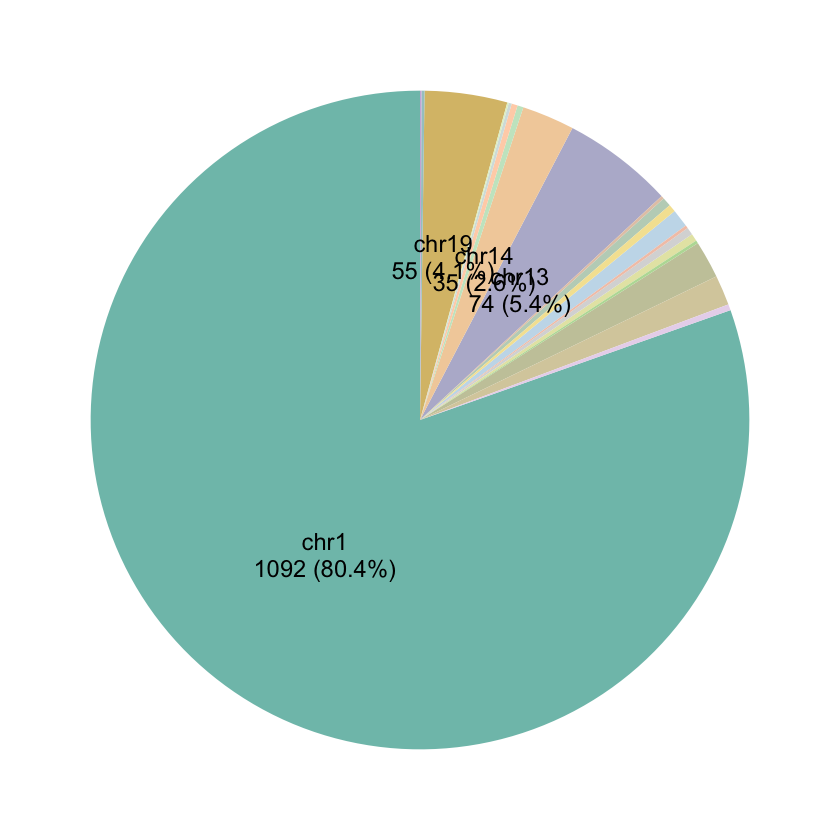

In [ ]:
# Supplementary Figure 4D: pie plot
library(ggplot2)
library(scales)
library(forcats)

pie_df <- step4 %>%
  count(chr, name = "n") %>%
  mutate(
    chr_num = suppressWarnings(as.numeric(str_remove(chr, "^chr"))),
    chr_ord = case_when(
      chr == "chrX" ~ 23,
      chr == "chrY" ~ 24,
      TRUE ~ chr_num
    )
  ) %>%
  arrange(chr_ord) %>%
  mutate(
    pct = n / sum(n),
    label = paste0(chr, "\n", n, " (", percent(pct, accuracy = 0.1), ")")
  )

top_n_label <- 4
pie_df <- pie_df %>%
  dplyr::arrange(dplyr::desc(n)) %>%
  dplyr::mutate(
    rank_n = dplyr::row_number(),
    label_show = ifelse(rank_n <= top_n_label, label, "")
  )

p_pie <- ggplot(pie_df, aes(x = "", y = n, fill = fct_reorder(chr, chr_ord))) +
  geom_col(width = 1, color = NA) +
  coord_polar(theta = "y") +
  geom_text(
    aes(label = label_show),
    position = position_stack(vjust = 0.5),
    size = 5,
    lineheight = 0.95
  ) +
  scale_fill_manual(values = c(
    "#7FC1B8","#E8D7ED","#D8CEAB","#C8C9A8","#B9DCA4","#E5E5B2",
    "#D9D9D9","#F2C7B5","#C7DCEB","#F4E3A1","#BFD3C1","#E3C8B3",
    "#B8B8D1","#F2D0A9","#C8E6C9","#FFD3B6","#D5E1DF","#E2F0CB",
    "#D9BF77","#A5C9CA","#CDB4DB","#F1C0E8","#CFBAF0","#B8E0D2"
  )) +
  theme_void(base_size = 14) +
  theme(
    legend.position = "none",
    plot.margin = margin(5, 5, 5, 5)
  )

ggsave("chr_pie_bottom_right.png", p_pie, width = 6, height = 6, dpi = 300, bg = "white")
ggsave("chr_pie_bottom_right.pdf", p_pie, width = 6, height = 6, bg = "white")

p_pie


In [69]:
chr_table <- pie_df %>%
  dplyr::transmute(
    Chromosome = chr,
    SNP_Count = n,
    Percent = scales::percent(pct, accuracy = 0.1),
    chr_num = suppressWarnings(as.numeric(stringr::str_remove(chr, "^chr"))),
    chr_ord = dplyr::case_when(
      chr == "chrX" ~ 23,
      chr == "chrY" ~ 24,
      TRUE ~ chr_num
    )
  ) %>%
  dplyr::arrange(chr_ord) %>%
  dplyr::select(Chromosome, SNP_Count, Percent)

print(chr_table)
readr::write_csv(chr_table, "chromosome_snp_count_table_chr_order.csv")


# A tibble: 21 × 3
   Chromosome SNP_Count Percent
   <chr>          <int> <chr>  
 1 chr1            1092 80.4%  
 2 chr2               4 0.3%   
 3 chr3              20 1.5%   
 4 chr4              25 1.8%   
 5 chr5               2 0.1%   
 6 chr6               5 0.4%   
 7 chr7               5 0.4%   
 8 chr8               2 0.1%   
 9 chr9              12 0.9%   
10 chr10              5 0.4%   
# ℹ 11 more rows


In [ ]:
# Supplementary Figure 4D
#download.file("https://hgdownload.soe.ucsc.edu/goldenPath/hg19/database/cytoBand.txt.gz",destfile = "cytoBand_hg19.txt.gz",mode = "wb")
library(dplyr)
library(stringr)
library(data.table)

cyto <- fread("cytoBand_hg19.txt.gz", header = FALSE)
colnames(cyto) <- c("chr", "start", "end", "band", "stain")

# chr1
cyto1 <- cyto %>%
  filter(chr == "chr1") %>%
  mutate(
    start = as.integer(start),
    end   = as.integer(end),
    band  = as.character(band)
  )


# step4 ：SNP_id, chr, pos
snp1 <- step4 %>%
  filter(chr == "chr1") %>%
  transmute(
    SNP_id = as.character(SNP_id),
    pos    = as.integer(pos)
  ) %>%
  filter(!is.na(pos), pos > 0)

setDT(snp1); setDT(cyto1)
setkey(cyto1, start, end)

mapped <- foverlaps(
  snp1[, .(SNP_id, pos, start = pos, end = pos + 1L)],
  cyto1[, .(chr, start, end, band)],
  by.x = c("start", "end"),
  by.y = c("start", "end"),
  type = "within",
  nomatch = NA
)

mapped_df <- as.data.frame(mapped) %>%
  mutate(
    Cytoband = ifelse(is.na(band), "Other", band)
  )

library(scales)

band_df <- mapped_df %>%
  count(Cytoband, name = "n") %>%
  arrange(desc(n)) %>%
  mutate(
    pct = n / sum(n)
  )

cutoff <- 0.01
band_df2 <- band_df %>%
  mutate(Cytoband2 = ifelse(pct < cutoff, "Other", Cytoband)) %>%
  group_by(Cytoband2) %>%
  summarise(n = sum(n), .groups = "drop") %>%
  mutate(
    pct = n / sum(n),
    label = paste0(Cytoband2, "\n", n, "(", percent(pct, accuracy = 0.1), ")")
  ) %>%
  arrange(desc(n))



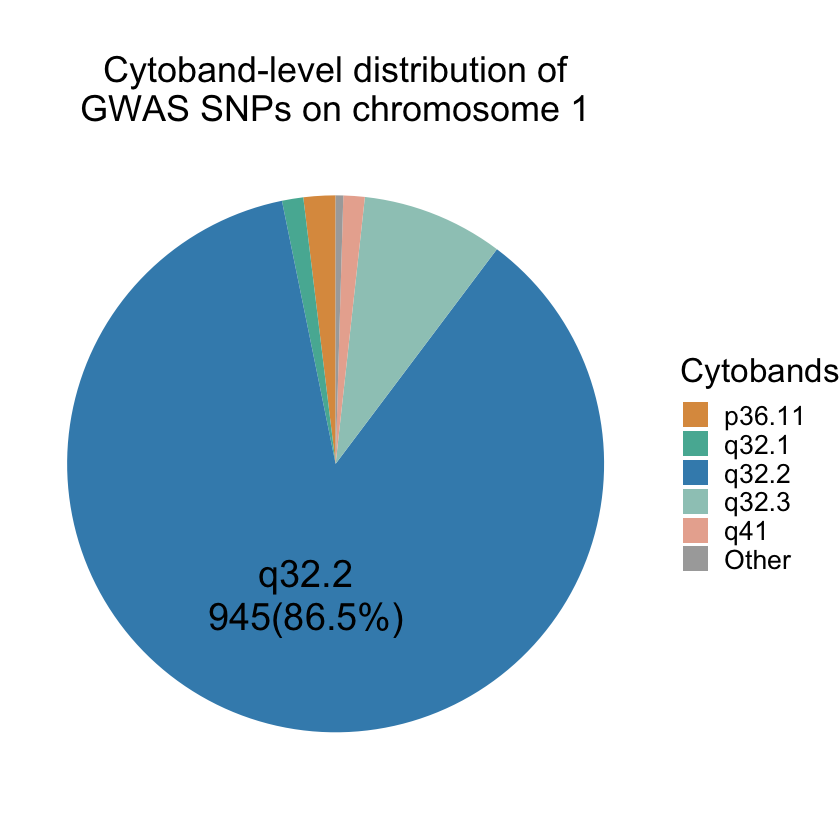

In [ ]:
library(dplyr)
library(scales)
library(readr)
library(ggplot2)
library(dplyr)
library(forcats)


cytoband_table <- plot_df %>%
  mutate(
    Percent = percent(n / sum(n), accuracy = 0.1)
  ) %>%
  transmute(
    Cytoband = as.character(Cytoband2),
    SNP_Count = n,
    Percent = Percent
  ) %>%
  arrange(desc(SNP_Count))

print(cytoband_table)


write_csv(cytoband_table, "chr1_cytoband_snp_table.csv")

total_row <- cytoband_table %>%
  summarise(
    Cytoband = "Total",
    SNP_Count = sum(SNP_Count),
    Percent = percent(sum(SNP_Count) / sum(SNP_Count), accuracy = 0.1)
  )

cytoband_table_with_total <- bind_rows(cytoband_table, total_row)

print(cytoband_table_with_total)
write_csv(cytoband_table_with_total, "chr1_cytoband_snp_table_with_total.csv")

band_levels <- c("p36.11", "q32.1", "q32.2", "q32.3", "q41", "Other")

band_colors <- c(
  "p36.11" = "#DD9A4D",
  "q32.1"  = "#56B4A2",
  "q32.2"  = "#3F8DBA",
  "q32.3"  = "#9DC9C0",
  "q41"    = "#E9B09E",
  "Other"  = "#A9A9A9"
)

plot_df <- band_df2 %>%
  mutate(
    Cytoband2 = ifelse(Cytoband2 %in% band_levels, Cytoband2, "Other"),
    Cytoband2 = factor(Cytoband2, levels = band_levels)
  ) %>%
  group_by(Cytoband2) %>%
  summarise(n = sum(n), .groups = "drop") %>%
  mutate(
    pct = n / sum(n),
    label = paste0(Cytoband2, "\n", n, "(", scales::percent(pct, accuracy = 0.1), ")")
  )


plot_df$label_show <- ""
plot_df$label_show[which.max(plot_df$n)] <- plot_df$label[which.max(plot_df$n)]

p_chr1_band <- ggplot(plot_df, aes(x = "", y = n, fill = Cytoband2)) +
  geom_col(width = 1, color = NA) +
  coord_polar(theta = "y") +
  geom_text(
    aes(label = label_show),
    position = position_stack(vjust = 0.5),
    size = 8,
    lineheight = 0.95
  ) +
  scale_fill_manual(values = band_colors, drop = FALSE) +
  labs(
    title = "Cytoband-level distribution of\nGWAS SNPs on chromosome 1",
    fill = "Cytobands"
  ) +
  theme_void(base_size = 18) +
  theme(
    plot.title = element_text(hjust = 0.5),
    legend.position = "right",
    legend.title = element_text(size = 20),
    legend.text  = element_text(size = 16)
  )

ggsave("chr1_cytoband_pie_match_color.png", p_chr1_band, width = 12, height = 8, dpi = 300, bg = "white")
ggsave("chr1_cytoband_pie_match_color.pdf", p_chr1_band, width = 12, height = 8, bg = "white")

p_chr1_band

# A tibble: 6 × 3
  Cytoband SNP_Count Percent
  <chr>        <int> <chr>  
1 q32.2          945 86.5%  
2 q32.3           93 8.5%   
3 p36.11          21 1.9%   
4 q32.1           14 1.3%   
5 q41             14 1.3%   
6 Other            5 0.5%   
# A tibble: 7 × 3
  Cytoband SNP_Count Percent
  <chr>        <int> <chr>  
1 q32.2          945 86.5%  
2 q32.3           93 8.5%   
3 p36.11          21 1.9%   
4 q32.1           14 1.3%   
5 q41             14 1.3%   
6 Other            5 0.5%   
7 Total         1092 100.0% 
